# POPPA Dataset Explorer
**File:** `final_data_v2/poppa_integrated_v2.csv`  
**Dataset:** Populism and Political Parties Expert Survey (POPPA) v2  
**Waves:** 2018 and 2023 | 31 European countries | 358 parties

---

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- UPDATE THIS PATH to wherever you saved the CSV ---
DATA_PATH = '/Users/Naam/Downloads/dataverse_files (1)/final_data_v2/poppa_integrated_v2.csv'

df = pd.read_csv(DATA_PATH, na_values='NA')

# Tidy wave labels
df['wave_year'] = df['wave'].str.extract(r'(\d{4})').astype(int)

print(f'Shape: {df.shape}')
print(f'Countries: {df.country.nunique()}')
print(f'Parties:   {df.poppa_id.nunique()}')
print(f'Waves:     {sorted(df.wave.unique())}')

Shape: (562, 42)
Countries: 31
Parties:   358
Waves:     ['Wave 1 - 2018', 'Wave 2 - 2023']


## 1. Dataset Overview

In [5]:
df.head(4)

,country,country_short,party_short,wave,party_name_english,party_name_original,family,family_label,poppa_id,partyfacts_id,...,climatepolicy,climatescience,complex,emotional,intradem,personalised,populism_mean,populism_cfa,populism_cfa_rescaled,wave_year
0,Austria,AUT,SPÖ,Wave 1 - 2018,Social Democratic Party of Austria,Sozialdemokratische Partei Österreichs,5,Social Democratic,101,1384.0,...,NaN,NaN,6.461538,4.846154,6.307692,6.230769,3.610256,-1.237190,3.230988,2018
1,Austria,AUT,SPÖ,Wave 2 - 2023,Social Democratic Party of Austria,Sozialdemokratische Partei Österreichs,5,Social Democratic,101,1384.0,...,5.153846,6.846154,NaN,NaN,NaN,NaN,2.039744,-2.770561,1.076932,2023
2,Austria,AUT,ÖVP,Wave 1 - 2018,Austrian People's Party,Österreichische Volkspartei,4,Christian Democratic,102,1329.0,...,NaN,NaN,4.769231,6.769231,4.538462,8.538462,4.701282,-0.132099,4.783403,2018
3,Austria,AUT,ÖVP,Wave 2 - 2023,Austrian People's Party,Österreichische Volkspartei,4,Christian Democratic,102,1329.0,...,3.538462,5.833333,NaN,NaN,NaN,NaN,2.643590,-2.119470,1.991574,2023


In [6]:
df.dtypes

country                      str
country_short                str
party_short                  str
wave                         str
party_name_english           str
party_name_original          str
family                     int64
family_label                 str
poppa_id                   int64
partyfacts_id            float64
n_experts                  int64
mean_n_experts           float64
manichean                float64
indivisible              float64
generalwill              float64
peoplecentrism           float64
antielitism              float64
peopleimm                float64
peoplewealthy            float64
elitepol                 float64
elitemedia               float64
eliteecon                float64
elitecult                float64
lrecon                   float64
salienceecon             float64
immigration              float64
nativism                 float64
lifestyle                float64
laworder                 float64
saliencecult             float64
lroverall 

In [7]:
# Summary statistics for all numeric variables
df.describe().round(2)

,family,poppa_id,partyfacts_id,n_experts,mean_n_experts,manichean,indivisible,generalwill,peoplecentrism,antielitism,...,climatepolicy,climatescience,complex,emotional,intradem,personalised,populism_mean,populism_cfa,populism_cfa_rescaled,wave_year
count,562.00,562.00,490.00,562.00,562.00,555.00,555.00,547.00,553.00,557.00,...,295.00,267.00,241.00,241.00,229.00,238.00,542.00,542.00,542.00,562.00
mean,4.62,1618.55,2444.21,10.29,9.02,5.39,4.55,4.95,5.06,4.71,...,4.96,5.98,4.83,6.09,4.83,6.31,4.93,-0.00,4.97,2020.78
std,2.68,873.58,2681.10,3.82,3.64,1.96,1.95,2.03,2.11,2.58,...,2.48,2.52,1.82,1.92,1.93,1.93,1.96,1.66,2.33,2.49
min,1.00,101.00,29.00,4.00,1.64,1.17,0.73,0.64,0.89,0.43,...,0.11,0.30,0.22,1.50,0.15,1.50,1.24,-3.54,0.00,2018.00
25%,2.00,811.25,656.00,8.00,6.56,3.79,3.00,3.43,3.38,2.44,...,3.10,4.50,3.44,4.67,3.40,5.00,3.33,-1.24,3.23,2018.00
50%,5.00,1605.50,1361.00,10.00,8.81,5.09,4.22,4.56,4.75,4.25,...,4.88,6.40,5.20,5.90,5.00,6.30,4.39,-0.46,4.33,2023.00
75%,7.00,2403.00,3206.00,12.00,10.68,7.00,6.00,6.59,6.75,7.11,...,6.84,7.95,6.27,7.57,6.21,7.83,6.57,1.29,6.78,2023.00
max,11.00,3207.00,9089.00,29.00,28.00,9.70,9.62,9.75,9.90,9.89,...,9.83,9.88,8.44,9.91,9.27,10.00,9.24,3.58,10.00,2023.00


## 2. Missingness Map
Critical for understanding which variables exist in which wave.

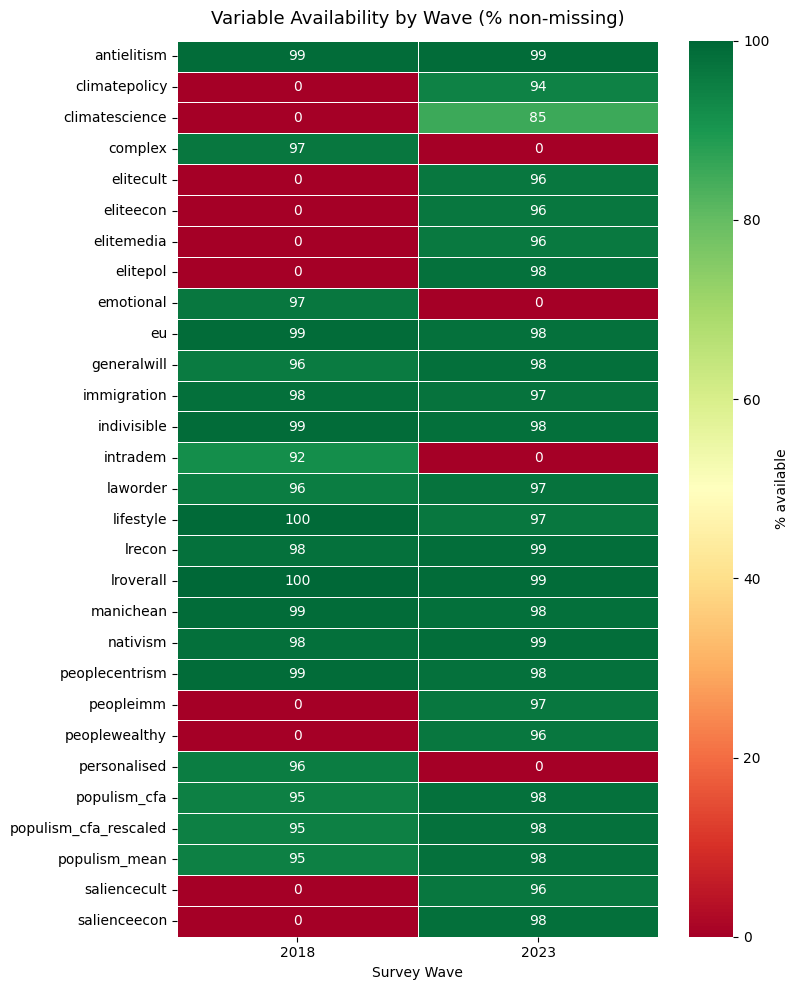


Wave 1 ONLY (missing in Wave 2): ['complex', 'emotional', 'intradem', 'personalised']
Wave 2 ONLY (missing in Wave 1): ['peopleimm', 'peoplewealthy', 'elitepol', 'elitemedia', 'eliteecon', 'elitecult', 'salienceecon', 'saliencecult', 'climatepolicy', 'climatescience']
Both waves: ['manichean', 'indivisible', 'generalwill', 'peoplecentrism', 'antielitism', 'lrecon', 'immigration', 'nativism', 'lifestyle', 'laworder', 'lroverall', 'eu', 'populism_mean', 'populism_cfa', 'populism_cfa_rescaled']


In [8]:
numeric_vars = [
    'manichean', 'indivisible', 'generalwill', 'peoplecentrism', 'antielitism',
    'peopleimm', 'peoplewealthy', 'elitepol', 'elitemedia', 'eliteecon', 'elitecult',
    'lrecon', 'salienceecon', 'immigration', 'nativism', 'lifestyle', 'laworder',
    'saliencecult', 'lroverall', 'eu', 'climatepolicy', 'climatescience',
    'complex', 'emotional', 'intradem', 'personalised',
    'populism_mean', 'populism_cfa', 'populism_cfa_rescaled'
]

# Availability by wave
avail = []
for var in numeric_vars:
    for wave_year in [2018, 2023]:
        sub = df[df.wave_year == wave_year]
        pct = sub[var].notna().mean() * 100
        avail.append({'variable': var, 'wave': wave_year, 'pct_available': pct})

avail_df = pd.DataFrame(avail).pivot(index='variable', columns='wave', values='pct_available')

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    avail_df, annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=0.5, vmin=0, vmax=100,
    cbar_kws={'label': '% available'},
    ax=ax
)
ax.set_title('Variable Availability by Wave (% non-missing)', fontsize=13, pad=12)
ax.set_xlabel('Survey Wave')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nWave 1 ONLY (missing in Wave 2):', [v for v in numeric_vars if avail_df.loc[v, 2018] > 50 and avail_df.loc[v, 2023] < 10])
print('Wave 2 ONLY (missing in Wave 1):', [v for v in numeric_vars if avail_df.loc[v, 2023] > 50 and avail_df.loc[v, 2018] < 10])
print('Both waves:', [v for v in numeric_vars if avail_df.loc[v, 2018] > 50 and avail_df.loc[v, 2023] > 50])

## 3. Populism Score Distributions

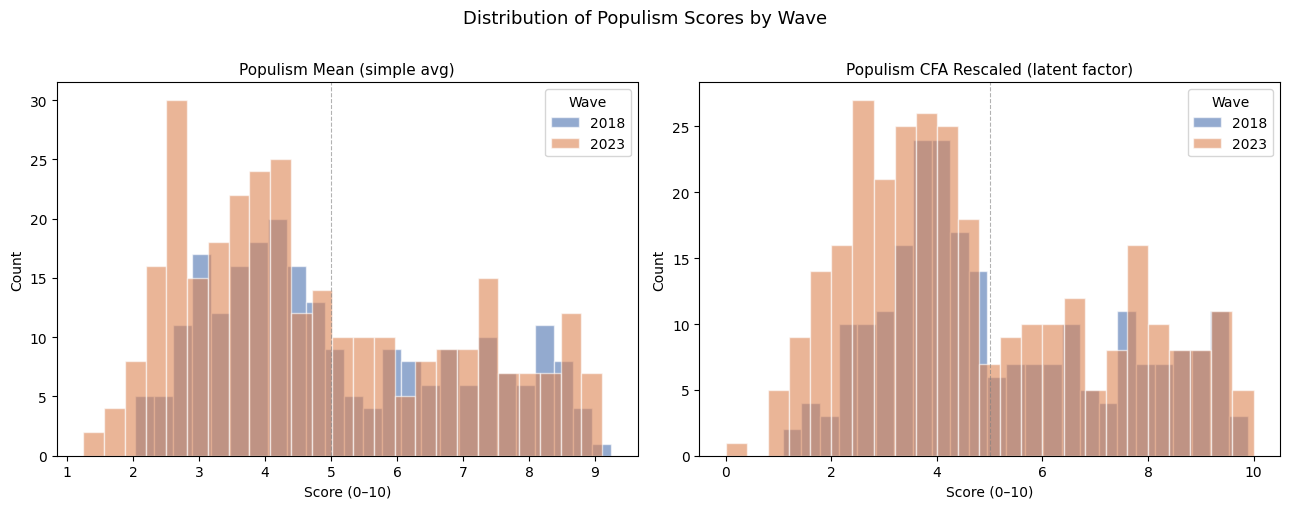

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {2018: '#4C72B0', 2023: '#DD8452'}

for ax, var, title in zip(
    axes,
    ['populism_mean', 'populism_cfa_rescaled'],
    ['Populism Mean (simple avg)', 'Populism CFA Rescaled (latent factor)']
):
    for wave_year, grp in df.groupby('wave_year'):
        vals = grp[var].dropna()
        ax.hist(vals, bins=25, alpha=0.6, label=str(wave_year), color=colors[wave_year], edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Score (0–10)')
    ax.set_ylabel('Count')
    ax.legend(title='Wave')
    ax.axvline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Distribution of Populism Scores by Wave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

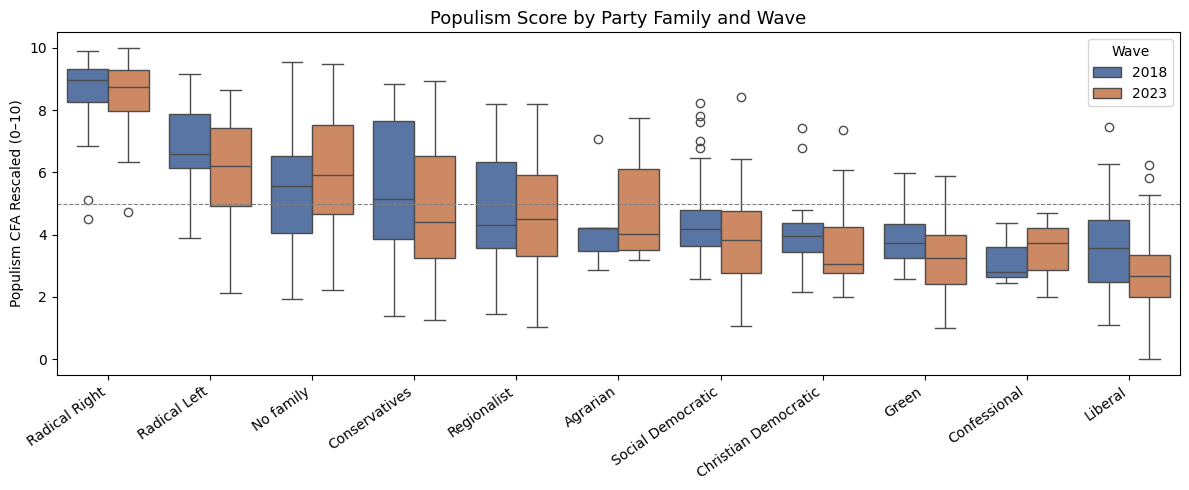

In [10]:
# By party family
fig, ax = plt.subplots(figsize=(12, 5))

family_order = (
    df.groupby('family_label')['populism_cfa_rescaled']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.boxplot(
    data=df, x='family_label', y='populism_cfa_rescaled',
    order=family_order, hue='wave_year', palette={2018: '#4C72B0', 2023: '#DD8452'},
    ax=ax
)
ax.set_title('Populism Score by Party Family and Wave', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Populism CFA Rescaled (0–10)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.axhline(5, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Wave')
plt.tight_layout()
plt.show()

## 4. Your Key Variable: `elitemedia`
*(Wave 2 / 2023 only — expert rating of whether the party views journalists as part of the corrupt elite)*

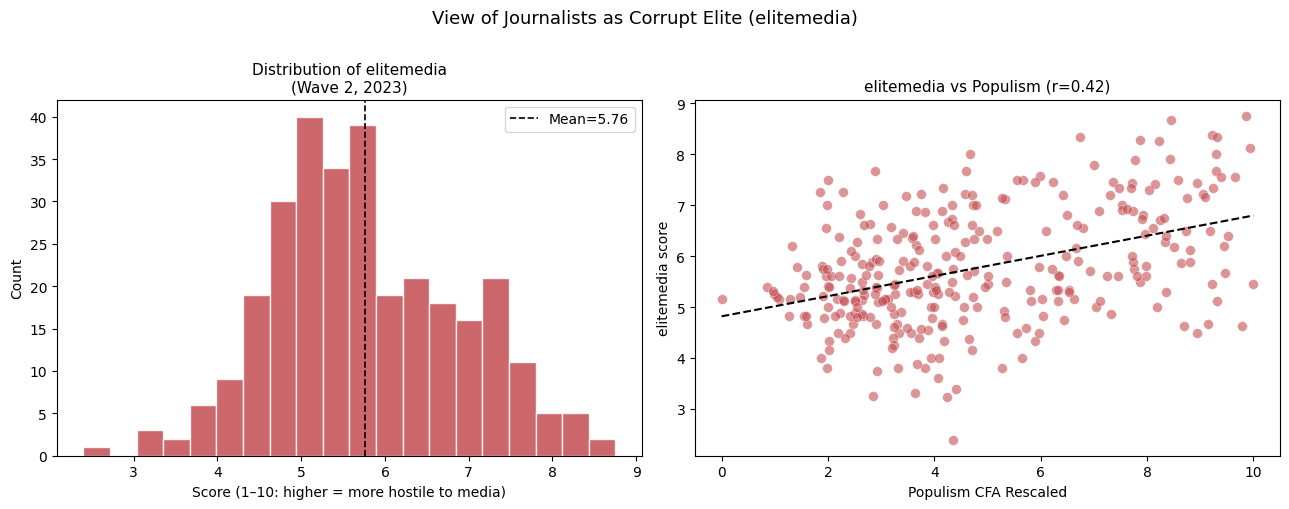

In [11]:
w2 = df[df.wave_year == 2023].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
axes[0].hist(w2['elitemedia'].dropna(), bins=20, color='#C44E52', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of elitemedia\n(Wave 2, 2023)', fontsize=11)
axes[0].set_xlabel('Score (1–10: higher = more hostile to media)')
axes[0].set_ylabel('Count')
axes[0].axvline(w2['elitemedia'].mean(), color='black', linestyle='--', linewidth=1.2, label=f"Mean={w2['elitemedia'].mean():.2f}")
axes[0].legend()

# elitemedia vs populism
axes[1].scatter(
    w2['populism_cfa_rescaled'], w2['elitemedia'],
    alpha=0.6, color='#C44E52', edgecolors='white', linewidths=0.4, s=50
)
# regression line
mask = w2['populism_cfa_rescaled'].notna() & w2['elitemedia'].notna()
m, b = np.polyfit(w2.loc[mask, 'populism_cfa_rescaled'], w2.loc[mask, 'elitemedia'], 1)
x_line = np.linspace(0, 10, 100)
axes[1].plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
corr = w2.loc[mask, ['populism_cfa_rescaled', 'elitemedia']].corr().iloc[0, 1]
axes[1].set_title(f'elitemedia vs Populism (r={corr:.2f})', fontsize=11)
axes[1].set_xlabel('Populism CFA Rescaled')
axes[1].set_ylabel('elitemedia score')

plt.suptitle('View of Journalists as Corrupt Elite (elitemedia)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

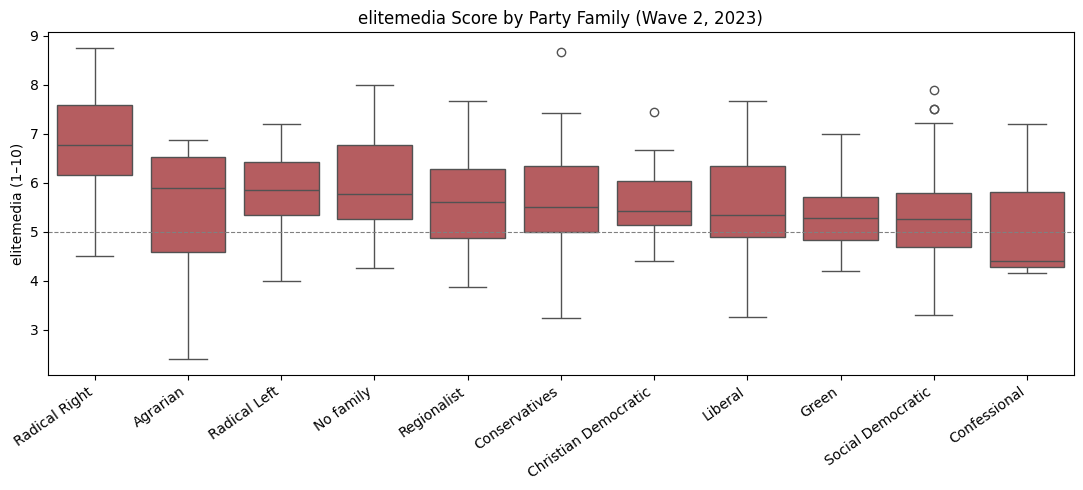

In [12]:
# elitemedia by party family
fig, ax = plt.subplots(figsize=(11, 5))

family_order_em = (
    w2.groupby('family_label')['elitemedia']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.boxplot(
    data=w2, x='family_label', y='elitemedia',
    order=family_order_em, color='#C44E52', ax=ax
)
ax.set_title('elitemedia Score by Party Family (Wave 2, 2023)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('elitemedia (1–10)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.axhline(5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

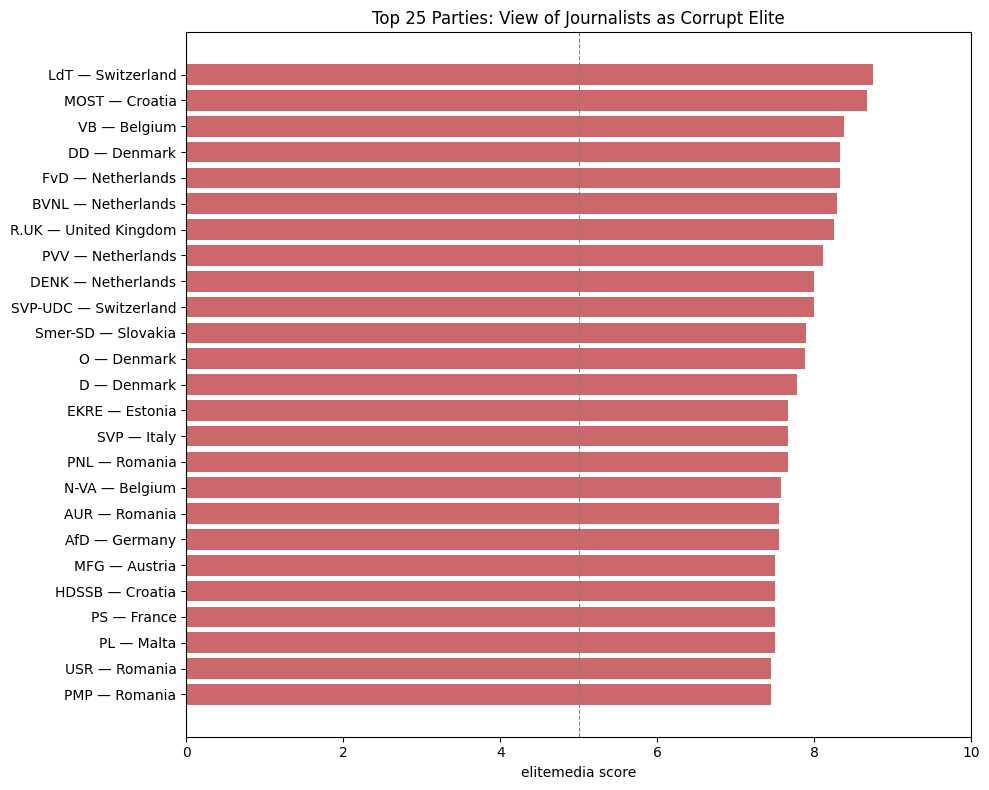

       country party_short         family_label  elitemedia  populism_cfa_rescaled  antielitism
   Switzerland         LdT        Radical Right    8.750000               9.860941     9.500000
       Croatia        MOST        Conservatives    8.666667               8.448681     8.875000
       Belgium          VB        Radical Right    8.375000               9.216100     9.111111
       Denmark          DD        Radical Right    8.333333               6.742645     8.777778
   Netherlands         FvD        Radical Right    8.333333               9.308464     9.333333
   Netherlands        BVNL        Radical Right    8.285714               7.862479     8.625000
United Kingdom        R.UK        Radical Right    8.250000               8.230690     8.333333
   Netherlands         PVV        Radical Right    8.111111               9.932461     9.700000
   Netherlands        DENK            No family    8.000000               4.671392     6.444444
   Switzerland     SVP-UDC        Radica

In [13]:
# Top 25 parties by elitemedia
top_em = w2.dropna(subset=['elitemedia']).nlargest(25, 'elitemedia')[[
    'country', 'party_short', 'family_label', 'elitemedia', 'populism_cfa_rescaled', 'antielitism'
]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_em['party_short'] + ' (' + top_em['country_short'].map(dict(zip(df.country, df.country_short))) + ')'
    if 'country_short' in top_em else top_em['party_short'],
    top_em['elitemedia'],
    color='#C44E52', alpha=0.85
)

# Add country labels
labels = [f"{r.party_short} — {r.country}" for _, r in top_em.iterrows()]
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('elitemedia score')
ax.set_title('Top 25 Parties: View of Journalists as Corrupt Elite', fontsize=12)
ax.set_xlim(0, 10)
ax.axvline(5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print(top_em.to_string(index=False))

## 5. Core Populism Components
The five items that make up the populism measurement (available in both waves).

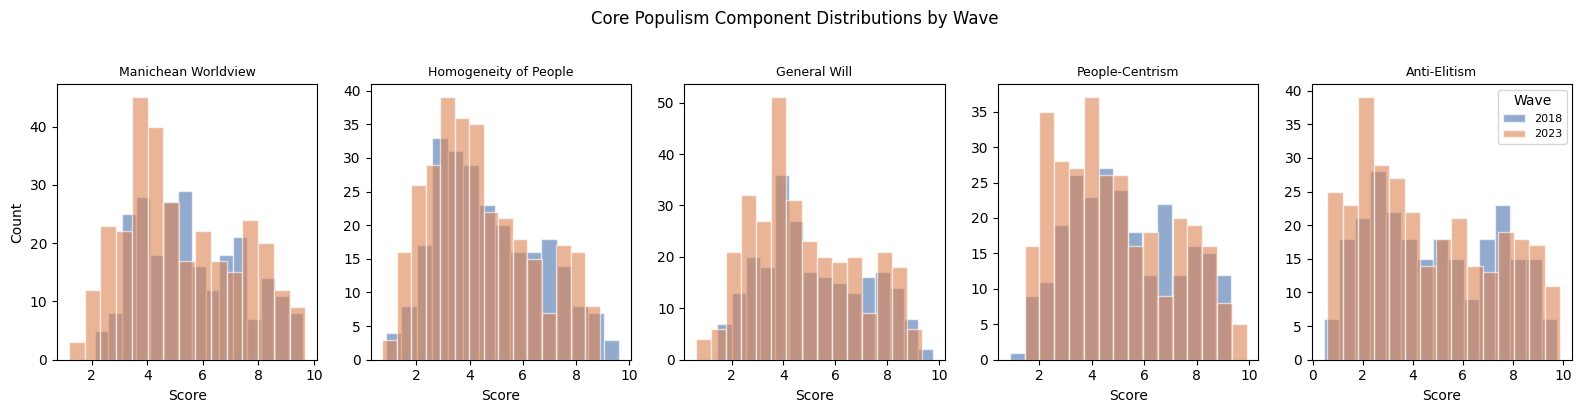

In [14]:
core_items = ['manichean', 'indivisible', 'generalwill', 'peoplecentrism', 'antielitism']
core_labels = {
    'manichean': 'Manichean Worldview',
    'indivisible': 'Homogeneity of People',
    'generalwill': 'General Will',
    'peoplecentrism': 'People-Centrism',
    'antielitism': 'Anti-Elitism'
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)

for ax, var in zip(axes, core_items):
    for wave_year, grp in df.groupby('wave_year'):
        vals = grp[var].dropna()
        ax.hist(vals, bins=15, alpha=0.6, label=str(wave_year), color=colors[wave_year], edgecolor='white')
    ax.set_title(core_labels[var], fontsize=9)
    ax.set_xlabel('Score')
    if ax == axes[0]:
        ax.set_ylabel('Count')

axes[-1].legend(title='Wave', fontsize=8)
plt.suptitle('Core Populism Component Distributions by Wave', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

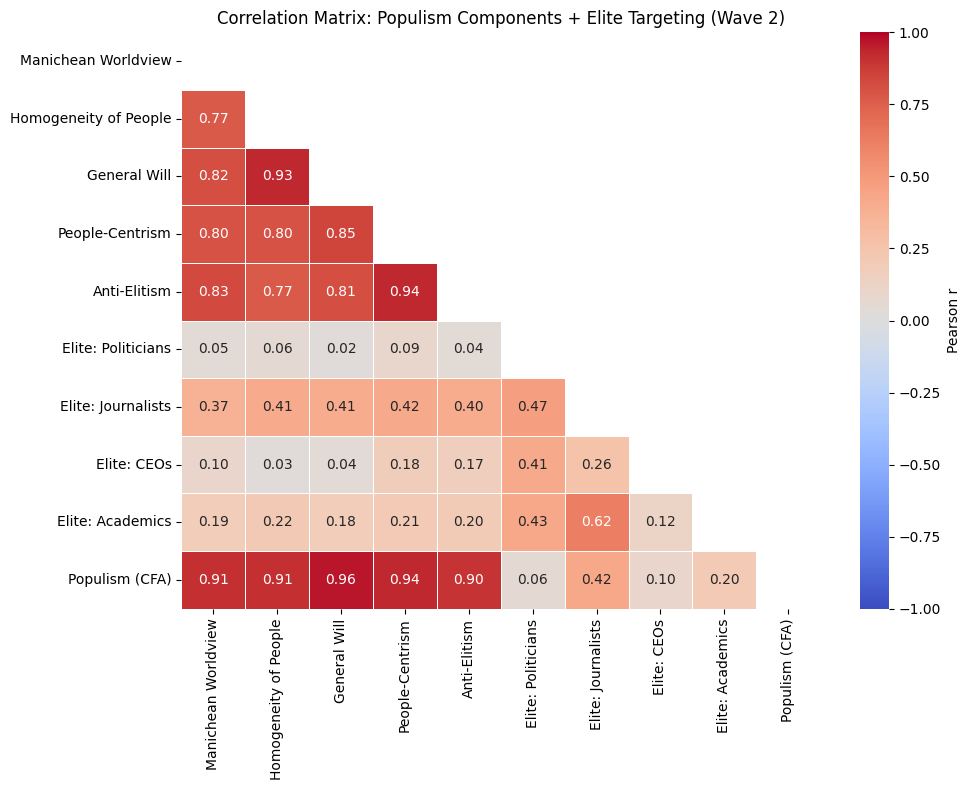

In [15]:
# Correlation matrix of core items + elite targeting variables (Wave 2)
elite_vars = ['elitepol', 'elitemedia', 'eliteecon', 'elitecult']
corr_vars = core_items + elite_vars + ['populism_cfa_rescaled']

corr_labels = {**core_labels,
    'elitepol': 'Elite: Politicians',
    'elitemedia': 'Elite: Journalists',
    'eliteecon': 'Elite: CEOs',
    'elitecult': 'Elite: Academics',
    'populism_cfa_rescaled': 'Populism (CFA)'
}

corr_matrix = w2[corr_vars].corr()
corr_matrix.index = [corr_labels[v] for v in corr_vars]
corr_matrix.columns = [corr_labels[v] for v in corr_vars]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix: Populism Components + Elite Targeting (Wave 2)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Country-Level Profiles

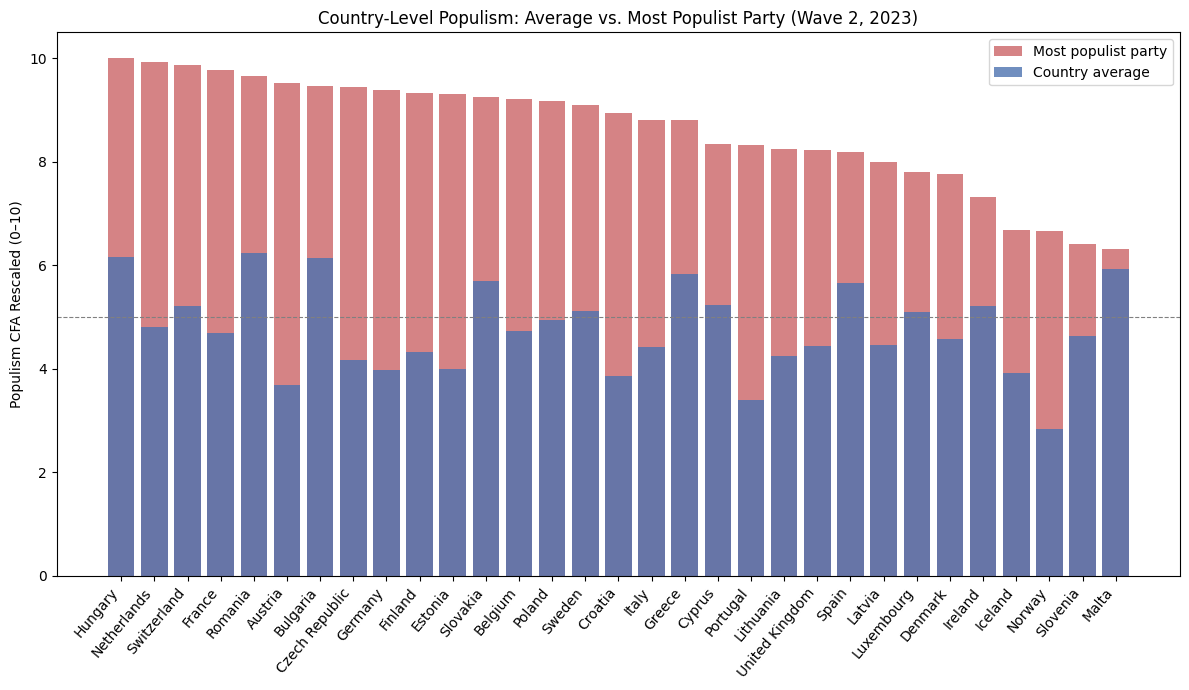

In [16]:
# Average populism score per country (Wave 2), weighted by nothing (all parties equal)
country_pop = (
    w2.groupby('country')['populism_cfa_rescaled']
    .agg(['mean', 'max', 'count'])
    .rename(columns={'mean': 'avg_populism', 'max': 'max_populism', 'count': 'n_parties'})
    .sort_values('max_populism', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(country_pop))
ax.bar(x, country_pop['max_populism'], color='#C44E52', alpha=0.7, label='Most populist party')
ax.bar(x, country_pop['avg_populism'], color='#4C72B0', alpha=0.8, label='Country average')
ax.set_xticks(x)
ax.set_xticklabels(country_pop.index, rotation=50, ha='right')
ax.set_ylabel('Populism CFA Rescaled (0–10)')
ax.set_title('Country-Level Populism: Average vs. Most Populist Party (Wave 2, 2023)', fontsize=12)
ax.axhline(5, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

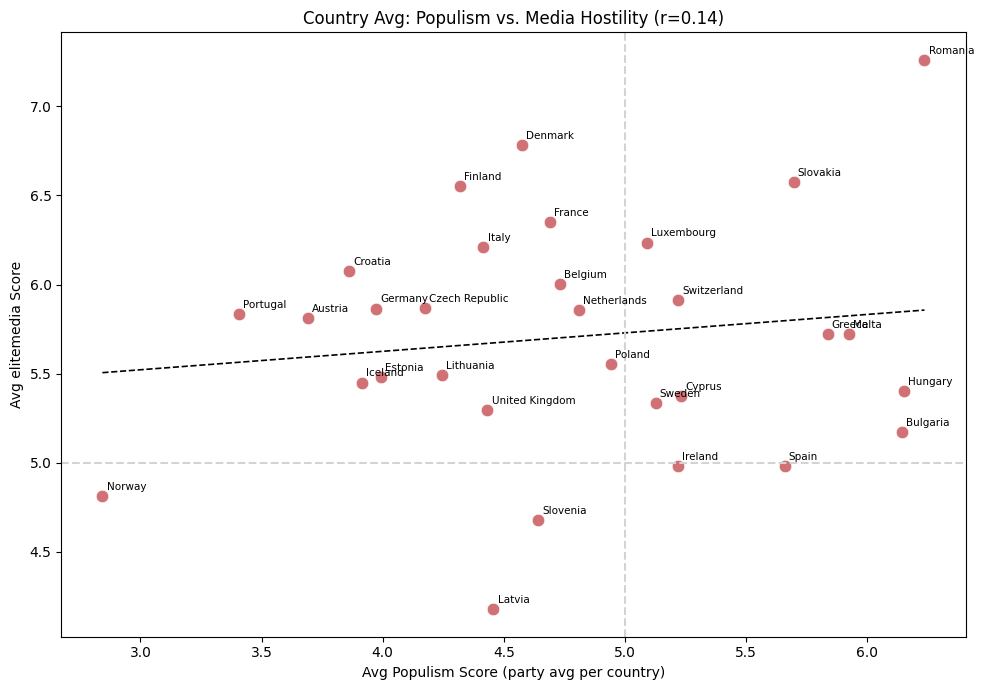

In [17]:
# Country-level elitemedia vs populism scatter
country_w2 = w2.groupby('country')[['populism_cfa_rescaled', 'elitemedia', 'antielitism']].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    country_w2['populism_cfa_rescaled'],
    country_w2['elitemedia'],
    s=80, alpha=0.8, color='#C44E52', edgecolors='white', linewidths=0.5
)
for _, row in country_w2.iterrows():
    ax.annotate(
        row['country'], (row['populism_cfa_rescaled'], row['elitemedia']),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

# Regression line
mask = country_w2['populism_cfa_rescaled'].notna() & country_w2['elitemedia'].notna()
m, b = np.polyfit(country_w2.loc[mask, 'populism_cfa_rescaled'], country_w2.loc[mask, 'elitemedia'], 1)
x_line = np.linspace(country_w2['populism_cfa_rescaled'].min(), country_w2['populism_cfa_rescaled'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.2)

corr_c = country_w2.loc[mask, ['populism_cfa_rescaled', 'elitemedia']].corr().iloc[0, 1]
ax.set_title(f'Country Avg: Populism vs. Media Hostility (r={corr_c:.2f})', fontsize=12)
ax.set_xlabel('Avg Populism Score (party avg per country)')
ax.set_ylabel('Avg elitemedia Score')
ax.axhline(5, color='lightgrey', linestyle='--')
ax.axvline(5, color='lightgrey', linestyle='--')
plt.tight_layout()
plt.show()

## 7. Wave 1 vs Wave 2 Change in Populism
*(For parties appearing in both waves)*

Parties in both waves: 189
Mean change 2018→2023: -0.38
Increased populism: 67 parties
Decreased populism: 122 parties


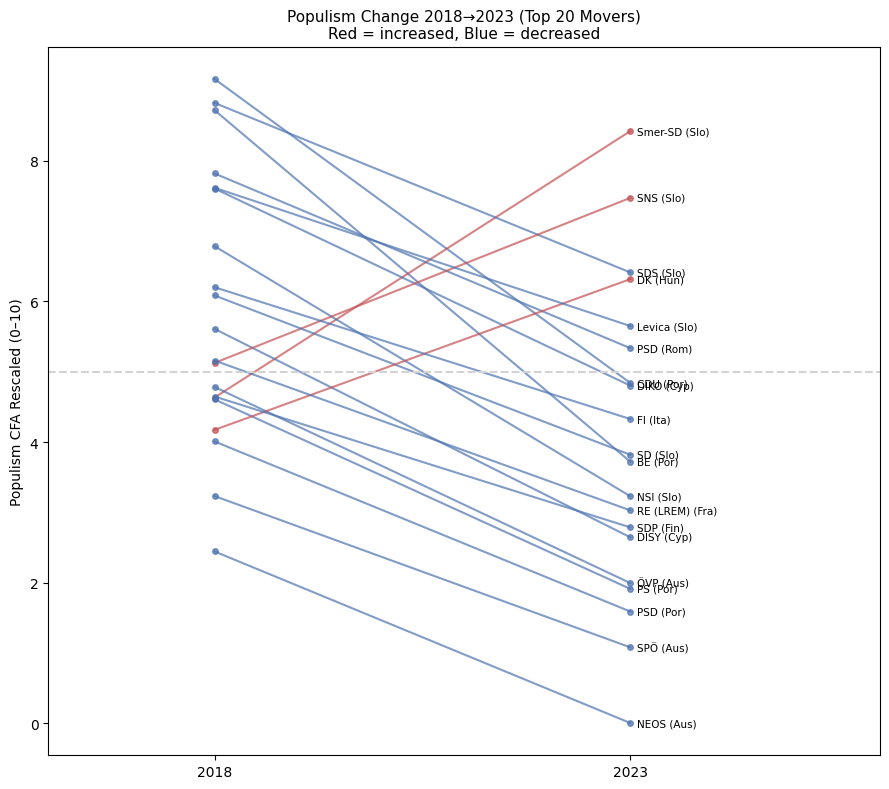

In [18]:
# Parties in both waves
w1 = df[df.wave_year == 2018]
both = pd.merge(
    w1[['poppa_id', 'party_short', 'country', 'family_label', 'populism_cfa_rescaled']].rename(columns={'populism_cfa_rescaled': 'pop_2018'}),
    w2[['poppa_id', 'populism_cfa_rescaled', 'elitemedia']].rename(columns={'populism_cfa_rescaled': 'pop_2023'}),
    on='poppa_id'
).dropna(subset=['pop_2018', 'pop_2023'])

both['change'] = both['pop_2023'] - both['pop_2018']

print(f'Parties in both waves: {len(both)}')
print(f'Mean change 2018→2023: {both["change"].mean():.2f}')
print(f'Increased populism: {(both.change > 0).sum()} parties')
print(f'Decreased populism: {(both.change < 0).sum()} parties')

# Slope chart for biggest movers
big_movers = both.reindex(both['change'].abs().nlargest(20).index)

fig, ax = plt.subplots(figsize=(9, 8))
for _, row in big_movers.iterrows():
    color = '#C44E52' if row['change'] > 0 else '#4C72B0'
    ax.plot([2018, 2023], [row['pop_2018'], row['pop_2023']], color=color, alpha=0.7, linewidth=1.5, marker='o', markersize=4)
    ax.annotate(f"{row['party_short']} ({row['country'][:3]})",
                xy=(2023, row['pop_2023']), fontsize=7.5, va='center', ha='left', xytext=(5, 0), textcoords='offset points')

ax.set_xlim(2016, 2026)
ax.set_xticks([2018, 2023])
ax.set_ylabel('Populism CFA Rescaled (0–10)')
ax.set_title('Populism Change 2018→2023 (Top 20 Movers)\nRed = increased, Blue = decreased', fontsize=11)
ax.axhline(5, color='lightgrey', linestyle='--')
plt.tight_layout()
plt.show()

## 8. Variables Relevant to Your RQ
Populism + Media Hostility → SLAPPs

In [19]:
rq_vars = ['populism_cfa_rescaled', 'elitemedia', 'antielitism', 'manichean', 'emotional', 'personalised']

# Scatter matrix (Wave 2 where possible, Wave 1 for emotional/personalised)
# Use Wave 2 for all available, note missingness
rq_data = w2[['country', 'party_short', 'family_label'] + rq_vars].copy()

print('Availability of RQ variables in Wave 2 (2023):')
for v in rq_vars:
    n = rq_data[v].notna().sum()
    print(f'  {v:30s}: {n}/{len(rq_data)} ({100*n/len(rq_data):.0f}%)')

print('\nNote: emotional/personalised are Wave 1 only. Use antielitism+manichean as proxies in Wave 2.')

Availability of RQ variables in Wave 2 (2023):
  populism_cfa_rescaled         : 306/313 (98%)
  elitemedia                    : 301/313 (96%)
  antielitism                   : 310/313 (99%)
  manichean                     : 308/313 (98%)
  emotional                     : 0/313 (0%)
  personalised                  : 0/313 (0%)

Note: emotional/personalised are Wave 1 only. Use antielitism+manichean as proxies in Wave 2.


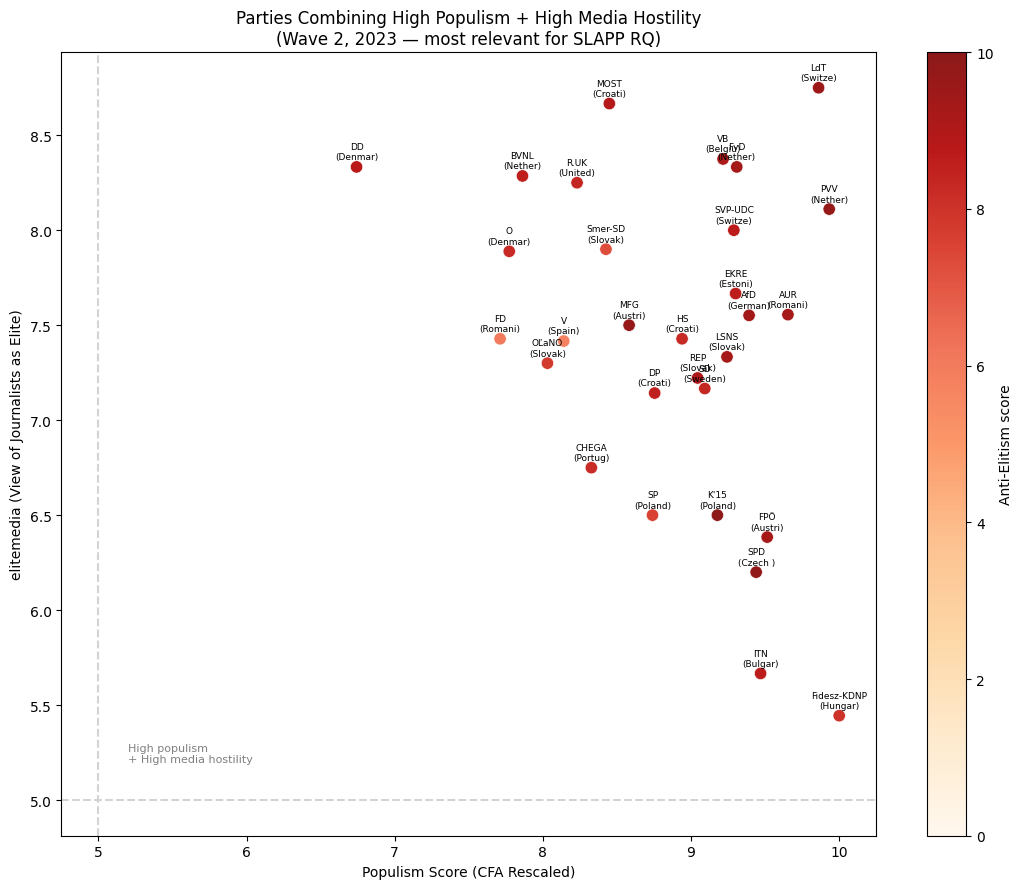

       country party_short      family_label  populism_cfa_rescaled  elitemedia  antielitism  rq_score
   Switzerland         LdT     Radical Right               9.860941    8.750000     9.500000  9.305471
   Netherlands         PVV     Radical Right               9.932461    8.111111     9.700000  9.021786
   Netherlands         FvD     Radical Right               9.308464    8.333333     9.333333  8.820899
       Belgium          VB     Radical Right               9.216100    8.375000     9.111111  8.795550
   Switzerland     SVP-UDC     Radical Right               9.288807    8.000000     8.700000  8.644403
       Romania         AUR     Radical Right               9.653981    7.555556     9.300000  8.604768
       Croatia        MOST     Conservatives               8.448681    8.666667     8.875000  8.557674
       Estonia        EKRE     Radical Right               9.300750    7.666667     8.666667  8.483708
       Germany         AfD     Radical Right               9.391766    7.

In [20]:
# High populism + high elitemedia = most at-risk parties for your RQ
w2['rq_score'] = (w2['populism_cfa_rescaled'].fillna(5) + w2['elitemedia'].fillna(5)) / 2

top_rq = w2.nlargest(30, 'rq_score')[[
    'country', 'party_short', 'family_label',
    'populism_cfa_rescaled', 'elitemedia', 'antielitism', 'rq_score'
]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 9))
scatter = ax.scatter(
    top_rq['populism_cfa_rescaled'],
    top_rq['elitemedia'],
    c=top_rq['antielitism'],
    cmap='OrRd', s=80, alpha=0.9,
    edgecolors='white', linewidths=0.5,
    vmin=0, vmax=10
)
plt.colorbar(scatter, ax=ax, label='Anti-Elitism score')

for _, row in top_rq.iterrows():
    ax.annotate(
        f"{row['party_short']}\n({row['country'][:6]})",
        (row['populism_cfa_rescaled'], row['elitemedia']),
        fontsize=6.5, ha='center', va='bottom',
        xytext=(0, 4), textcoords='offset points'
    )

ax.set_xlabel('Populism Score (CFA Rescaled)')
ax.set_ylabel('elitemedia (View of Journalists as Elite)')
ax.set_title('Parties Combining High Populism + High Media Hostility\n(Wave 2, 2023 — most relevant for SLAPP RQ)', fontsize=12)
ax.axhline(5, color='lightgrey', linestyle='--')
ax.axvline(5, color='lightgrey', linestyle='--')
ax.text(5.2, 5.2, 'High populism\n+ High media hostility', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

print(top_rq.to_string(index=False))

## 9. Merge Preparation for V-Dem
Create a clean country-level dataset ready to join with V-Dem.

In [21]:
# Strategy: identify governing/largest party per country per wave,
# OR aggregate all parties to country-level (max = most extreme, mean = avg landscape)

# Option A: Country-level aggregates from Wave 2
country_merge = w2.groupby(['country', 'country_short']).agg(
    n_parties=('poppa_id', 'count'),
    pop_mean=('populism_cfa_rescaled', 'mean'),
    pop_max=('populism_cfa_rescaled', 'max'),       # most populist party
    elitemedia_mean=('elitemedia', 'mean'),
    elitemedia_max=('elitemedia', 'max'),
    antielitism_mean=('antielitism', 'mean'),
    antielitism_max=('antielitism', 'max'),
    manichean_mean=('manichean', 'mean'),
).reset_index()

country_merge['wave_year'] = 2023

print('Country-level merge-ready dataset (Wave 2):')
print(f'Shape: {country_merge.shape}')
print()
print('Link to V-Dem using: country_short (ISO-3) + wave_year')
print('V-Dem key variables: v2meharjrn, v2xlg_legcon, v2x_jucon, v2x_libdem')
print()
country_merge.head(10)

Country-level merge-ready dataset (Wave 2):
Shape: (31, 11)

Link to V-Dem using: country_short (ISO-3) + wave_year
V-Dem key variables: v2meharjrn, v2xlg_legcon, v2x_jucon, v2x_libdem



,country,country_short,n_parties,pop_mean,pop_max,elitemedia_mean,elitemedia_max,antielitism_mean,antielitism_max,manichean_mean,wave_year
0,Austria,AUT,6,3.691762,9.513991,5.814103,7.500000,4.524786,9.700000,4.261364,2023
1,Belgium,BEL,13,4.731780,9.216100,6.002747,8.375000,4.382479,9.111111,5.179487,2023
2,Bulgaria,BGR,9,6.143429,9.469262,5.173569,5.666667,5.247306,9.250000,5.890741,2023
3,Croatia,HRV,14,3.860804,8.939469,6.076531,8.666667,3.697704,8.875000,4.522959,2023
4,Cyprus,CYP,7,5.230615,8.343551,5.376190,6.285714,4.338776,8.142857,5.028571,2023
5,Czech Republic,CZE,9,4.172785,9.439497,5.866667,6.900000,4.236364,9.818182,5.044444,2023
6,Denmark,DNK,14,4.574109,7.773286,6.783447,8.333333,5.087018,8.777778,5.214286,2023
7,Estonia,EST,6,3.991865,9.300750,5.481481,7.666667,3.611111,8.666667,4.981481,2023
8,Finland,FIN,10,4.317330,9.319346,6.553333,7.222222,4.137273,9.100000,4.654343,2023
9,France,FRA,13,4.689811,9.778517,6.350198,7.500000,4.615385,9.444444,5.012821,2023


In [ ]:
# Save the merge-ready file
country_merge.to_csv('poppa_country_level_w2.csv', index=False)
print('Saved: poppa_country_level_w2.csv')
print('\nColumns:', country_merge.columns.tolist())

## 10. Quick Reference: What to Use for Your RQ

| Purpose | Variable | Wave | Notes |
|---|---|---|---|
| **Primary populism measure** | `populism_cfa_rescaled` | Both | Best validated; use as main IV |
| **Media hostility (direct)** | `elitemedia` | 2023 only | Journalists-as-elite framing |
| **Media hostility (proxy)** | `antielitism` | Both | Broader; use if you need 2018 |
| **Manichean framing** | `manichean` | Both | Amplifies hostile discourse |
| **Personalised leadership** | `personalised` | 2018 only | Leader-centrism relevant to SLAPPs |
| **Country merge key** | `country_short` | Both | ISO-3; links to V-Dem |
| **Party cross-ref** | `partyfacts_id` | Both | Links to other party databases |

**Recommended merge strategy:**  
Use **Wave 2 (2023)** for `elitemedia` → merge on `country_short` with V-Dem year=2023.  
Unit of analysis: **country-level** (aggregate party scores) or **governing-party-level** (requires external data on which party is in government).